# SOB4ES - Red Neuronal con Perdida Personalizada
### CRISP-ML(Q) - Fase 3 y 4: Desarrollo y evaluacion de los modelos

Este notebook extiende el MLP multisalida estandar con una **funcion de perdida personalizada** que penaliza las predicciones que no respetan la estructura de correlacion entre targets observada en los datos de entrenamiento.

La perdida tiene dos componentes:
- **MSE estandar:** minimiza el error de prediccion por target individualmente.
- **Penalizacion de correlacion:** compara la matriz de correlacion de las predicciones con la matriz de correlacion de los targets reales en el batch. Si el modelo predice valores que rompen las correlaciones biologicas conocidas (por ejemplo, diversidad alta de lombrices con diversidad muy baja de colémbolos cuando normalmente co-varian), la perdida aumenta.

El peso relativo entre ambos componentes se controla con el parametro `lambda_corr`.

**Datasets utilizados:**
- `train.csv` - Entrenamiento (70 %, estratificado por pais)
- `test.csv`  - Tuning / validacion cruzada (15 %)
- `eval.csv`  - Evaluacion final imparcial (15 %)

**Estructura del notebook:**
1. Configuracion
2. Carga de datos
3. Definicion de la perdida personalizada y tuning
4. Validacion cruzada
5. Importancia de variables
6. Entrenamiento de produccion
7. Evaluacion final

---
## 1. Configuracion del entorno


In [6]:
import os
import time
import warnings
import joblib
import pandas as pd
import numpy as np
import itertools
from pathlib import Path
import seaborn as sns

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.model_selection import RepeatedKFold
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error
from sklearn.inspection import permutation_importance
from sklearn.base import BaseEstimator, RegressorMixin

import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

warnings.filterwarnings('ignore')

DATA_DIR   = 'input/'
MODELS_DIR = 'output/models/mlp_custom/'
Path(MODELS_DIR).mkdir(parents=True, exist_ok=True)
Path('output/var/').mkdir(parents=True, exist_ok=True)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Dispositivo de computo: {DEVICE}')

TARGETS = [
    # Shannon diversity index
    'nematode_shannon_z',
    'macro_shannon_z',
    'earthworm_shannon_z',
    'orib_shannon_z',
    'meso_shannon_z',
    'coll_shannon_z',
    'bac_shannon_z',
    'fun_shannon_z',
    'euk_shannon_z',
    'oomy_shannon_z',
    'cerc_shannon_z',
    # Richness
    'macro_order_richness_z',
    'earthworm_richness_z',
    'orib_species_richness_z',
    'meso_species_richness_z',
    'coll_species_richness_z',
    'bac_asv_richness_z',
    'fun_asv_richness_z',
    'euk_asv_richness_z',
    'oomy_asv_richness_z',
    'cerc_asv_richness_z'
]


FEATURES_AUTORIZADAS = [
    'total_plant_cover_z',
    'clay_content_z',
    'silt_content_z',
    'sand_content_z',
    'aggregate_stability_z',
    'bulk_density_z',
    'soil_moisture_z',
    'as_z',
    'cu_z',
    'k_z',
    'mo_z',
    'ni_z',
    'p_z',
    'pb_z',
    'zn_z',
    'soil_ph_z',
    'plot_total_organic_c_z',
    'plot_total_n_z',
    'gee_temp_media_C_z',
    'gee_humedad_rel_pct_z',
    'gee_ndvi_verano_z',
    'dem_elevacion_m_z',
    'dem_pendiente_deg_z',
    'dem_orientacion_deg_z',
    'eu_clay_content_z',
    'eu_sand_content_z',
    'eu_silt_content_z',
    'eu_water_holding_capacity_z',
    'eu_cn_ratio_z',
    'eu_p_z',
    'eu_ph_z',
    'eu_as_z',
    'eu_organic_carbon_octop_z',
    'eu_zn_z'
]

print('Librerias y variables cargadas correctamente...')


# Paleta de colores unificada
PALETTE = {
    'blue':         '#7FA6C9',
    'blue_light':   '#AAD0F1',
    'green':        '#7FC8A9',
    'green_light':  '#BEE6D3',
    'purple':       '#A98FC7',
    'purple_light': '#D6C7EA',
    'gray':         '#9B9B9B',
    'gray_dark':    '#5C5C5C',
}

# Secuencia ciclica para graficos con N series/categorias (N puede superar 6)
PALETTE_CYCLE = [PALETTE['blue'], PALETTE['green'], PALETTE['purple'],
                 PALETTE['blue_light'], PALETTE['green_light'], PALETTE['purple_light']]

def palette_cycle(n):
    """Devuelve una lista de n colores repitiendo PALETTE_CYCLE si hace falta."""
    return list(itertools.islice(itertools.cycle(PALETTE_CYCLE), n))

# Colormap secuencial (blanco -> azul -> morado) para heatmaps/matrices de confusion
PALETTE_CMAP = LinearSegmentedColormap.from_list(
    'sob4es_palette', ['#FFFFFF', PALETTE['purple_light'], PALETTE['purple']]
)

Dispositivo de computo: cuda
Librerias y variables cargadas correctamente...


## 2. Carga de datos

Se cargan los tres datasets pre-generados (division 70/15/15, estratificada por pais).

| Archivo    | Uso                                      | Filas aprox. |
|------------|------------------------------------------|--------------|
| `train.csv`| Ajuste del modelo                        | 299          |
| `test.csv` | Tuning / validacion cruzada              | 64           |
| `eval.csv` | Evaluacion final imparcial               | 65           |

El dataset `eval.csv` no se utiliza hasta la seccion 7.

In [7]:
def cargar_csv(ruta, nombre):
    if not os.path.exists(ruta):
        raise FileNotFoundError(f'No se encontro: {ruta}')
    try:
        df = pd.read_csv(ruta, sep=',')
        if len(df.columns) < 5:
            df = pd.read_csv(ruta, sep=';')
    except Exception:
        df = pd.read_csv(ruta, sep=';')
    print(f'  {nombre}: {df.shape[0]} filas x {df.shape[1]} columnas')
    return df

print("Cargando datasets...")
df_train = cargar_csv(os.path.join(DATA_DIR, 'train.csv'), 'train.csv')
df_test  = cargar_csv(os.path.join(DATA_DIR, 'test.csv'),  'test.csv')
df_eval  = cargar_csv(os.path.join(DATA_DIR, 'eval.csv'),  'eval.csv')

X_train = df_train[FEATURES_AUTORIZADAS]
y_train = df_train[TARGETS]

X_test  = df_test[FEATURES_AUTORIZADAS]
y_test  = df_test[TARGETS]

X_eval  = df_eval[FEATURES_AUTORIZADAS]   # no se usa hasta la seccion 7
y_eval  = df_eval[TARGETS]               # no se usa hasta la seccion 7

print(f"\nDatasets cargados...")
print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}  |  X_eval: {X_eval.shape}")
print(f"y_train: {y_train.shape}  |  y_test: {y_test.shape}  |  y_eval: {y_eval.shape}")


Cargando datasets...
  train.csv: 299 filas x 71 columnas
  test.csv: 64 filas x 71 columnas
  eval.csv: 65 filas x 71 columnas

Datasets cargados...
X_train: (299, 34)  |  X_test: (64, 34)  |  X_eval: (65, 34)
y_train: (299, 21)  |  y_test: (64, 21)  |  y_eval: (65, 21)


## 3. Perdida personalizada y tuning

### Funcion de perdida

La perdida combina dos terminos:

```
Loss = MSE(y_pred, y_real)  +  lambda_corr * CorrelationPenalty(y_pred, y_real)
```

La penalizacion de correlacion se calcula como la diferencia de Frobenius entre la matriz de correlacion de las predicciones y la de los valores reales en cada batch:

```
CorrelationPenalty = || corr(y_pred) - corr(y_real) ||_F
```

Un `lambda_corr` alto fuerza al modelo a respetar las correlaciones biologicas pero puede perjudicar la precision individual por target. El tuning busca el valor optimo de este parametro junto a la arquitectura.

### Arquitectura

Identica al MLP estandar: capas densas con ReLU, Dropout y capa de salida lineal de 11 neuronas.

In [8]:
class MLPMultiSalida(nn.Module):
    def __init__(self, n_inputs, n_outputs, hidden_sizes, dropout_rate):
        super().__init__()
        layers = []
        in_size = n_inputs
        for h in hidden_sizes:
            layers += [nn.Linear(in_size, h), nn.ReLU(), nn.Dropout(dropout_rate)]
            in_size = h
        layers.append(nn.Linear(in_size, n_outputs))
        self.red = nn.Sequential(*layers)
    def forward(self, x):
        return self.red(x)


def correlation_matrix(y):
    """
    Calcula la matriz de correlacion de un tensor (batch x targets).
    Se usa para comparar las correlaciones entre targets predichos vs reales.
    """
    y_centered = y - y.mean(dim=0, keepdim=True)
    std = y_centered.std(dim=0, keepdim=True).clamp(min=1e-8)
    y_norm = y_centered / std
    return torch.mm(y_norm.T, y_norm) / y.shape[0]


class CorrelationAwareLoss(nn.Module):
    """
    Perdida personalizada que combina MSE con una penalizacion
    por diferencias en la estructura de correlacion entre targets.
    lambda_corr controla el peso de la penalizacion:
      - lambda_corr = 0.0: equivale a MSE puro
      - lambda_corr = 1.0: penalizacion de correlacion con mismo peso que MSE
    """
    def __init__(self, lambda_corr=0.1):
        super().__init__()
        self.lambda_corr = lambda_corr
        self.mse = nn.MSELoss()

    def forward(self, y_pred, y_real):
        mse_loss  = self.mse(y_pred, y_real)
        corr_pred = correlation_matrix(y_pred)
        corr_real = correlation_matrix(y_real)
        # Norma de Frobenius: penaliza diferencias elemento a elemento entre matrices
        corr_loss = torch.norm(corr_pred - corr_real, p='fro')
        return mse_loss + self.lambda_corr * corr_loss


def entrenar_mlp_custom(X_tr, y_tr, X_val, y_val, hidden_sizes, dropout, lr, epochs, batch_size, lambda_corr):
    X_t = torch.tensor(X_tr.values, dtype=torch.float32).to(DEVICE)
    y_t = torch.tensor(y_tr.values, dtype=torch.float32).to(DEVICE)
    X_v = torch.tensor(X_val.values, dtype=torch.float32).to(DEVICE)
    y_v = torch.tensor(y_val.values, dtype=torch.float32).to(DEVICE)

    loader    = DataLoader(TensorDataset(X_t, y_t), batch_size=batch_size, shuffle=True)
    model     = MLPMultiSalida(X_tr.shape[1], y_tr.shape[1], hidden_sizes, dropout).to(DEVICE)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    criterion = CorrelationAwareLoss(lambda_corr=lambda_corr)

    model.train()
    for epoch in range(epochs):
        for xb, yb in loader:
            optimizer.zero_grad()
            loss = criterion(model(xb), yb)
            loss.backward()
            optimizer.step()

    model.eval()
    with torch.no_grad():
        y_pred = model(X_v).cpu().numpy()
    r2 = r2_score(y_val.values, y_pred, multioutput='uniform_average')
    return model, r2


# Grid de hiperparametros: arquitectura + lambda_corr
grid = [
    {'hidden': [64, 32],       'dropout': 0.2, 'lr': 1e-3, 'epochs': 150, 'batch': 16, 'weight_decay': 1e-2, 'lambda_corr': 0.0},
    {'hidden': [64, 32],       'dropout': 0.2, 'lr': 1e-3, 'epochs': 150, 'batch': 16, 'weight_decay': 5e-3, 'lambda_corr': 0.05},
    {'hidden': [64, 32],       'dropout': 0.3, 'lr': 1e-3, 'epochs': 200, 'batch': 32, 'weight_decay': 5e-3, 'lambda_corr': 0.1},
    {'hidden': [128, 64],      'dropout': 0.3, 'lr': 1e-3, 'epochs': 200, 'batch': 32, 'weight_decay': 2e-3, 'lambda_corr': 0.05},
    {'hidden': [128, 64],      'dropout': 0.3, 'lr': 1e-3, 'epochs': 200, 'batch': 32, 'weight_decay': 2e-3, 'lambda_corr': 0.2},
    {'hidden': [128, 32],      'dropout': 0.3, 'lr': 5e-4, 'epochs': 250, 'batch': 16, 'weight_decay': 1e-3, 'lambda_corr': 0.1},
    {'hidden': [128, 32],      'dropout': 0.4, 'lr': 5e-4, 'epochs': 250, 'batch': 16, 'weight_decay': 2e-3, 'lambda_corr': 0.3},
    {'hidden': [64, 16, 8],    'dropout': 0.2, 'lr': 1e-3, 'epochs': 200, 'batch': 16, 'weight_decay': 1e-3, 'lambda_corr': 0.1},
    {'hidden': [64, 16, 8],    'dropout': 0.3, 'lr': 1e-3, 'epochs': 200, 'batch': 16, 'weight_decay': 5e-3, 'lambda_corr': 0.5},
    {'hidden': [128, 64, 32],  'dropout': 0.4, 'lr': 5e-4, 'epochs': 200, 'batch': 32, 'weight_decay': 5e-3, 'lambda_corr': 0.2}
]

print('Buscando mejor configuracion (arquitectura + lambda_corr)...\n')
mejor_r2     = -np.inf
mejor_config = None

for cfg in grid:
    _, r2 = entrenar_mlp_custom(
        X_train, y_train, X_test, y_test,
        cfg['hidden'], cfg['dropout'], cfg['lr'],
        cfg['epochs'], cfg['batch'], cfg['lambda_corr']
    )
    print(f'  hidden={str(cfg["hidden"]):20} lambda_corr={cfg["lambda_corr"]} -> R2 val: {r2:.4f}')
    if r2 > mejor_r2:
        mejor_r2     = r2
        mejor_config = cfg

print(f'\nMejor configuracion: {mejor_config}')
print(f'Mejor R2 de validacion: {mejor_r2:.4f}')
MLP_CONFIG = mejor_config


Buscando mejor configuracion (arquitectura + lambda_corr)...

  hidden=[64, 32]             lambda_corr=0.0 -> R2 val: 0.1606
  hidden=[64, 32]             lambda_corr=0.05 -> R2 val: 0.1250
  hidden=[64, 32]             lambda_corr=0.1 -> R2 val: 0.1440
  hidden=[128, 64]            lambda_corr=0.05 -> R2 val: 0.1491
  hidden=[128, 64]            lambda_corr=0.2 -> R2 val: 0.1212
  hidden=[128, 32]            lambda_corr=0.1 -> R2 val: 0.1486
  hidden=[128, 32]            lambda_corr=0.3 -> R2 val: 0.1229
  hidden=[64, 16, 8]          lambda_corr=0.1 -> R2 val: 0.1045
  hidden=[64, 16, 8]          lambda_corr=0.5 -> R2 val: -0.0038
  hidden=[128, 64, 32]        lambda_corr=0.2 -> R2 val: 0.0290

Mejor configuracion: {'hidden': [64, 32], 'dropout': 0.2, 'lr': 0.001, 'epochs': 150, 'batch': 16, 'weight_decay': 0.01, 'lambda_corr': 0.0}
Mejor R2 de validacion: 0.1606


## 4. Validacion cruzada

Se evalua la robustez de la configuracion optima con validacion cruzada repetida (5 pliegues x 3 repeticiones) sobre `X_train`. Se registra tanto el R2 global como el efecto que tiene `lambda_corr` sobre la consistencia de las predicciones entre pliegues.

Validacion cruzada repetida (15 evaluaciones sobre X_train)...

  Pliegues completados: 5/15  |  R2 medio hasta ahora: 0.1055
  Pliegues completados: 10/15  |  R2 medio hasta ahora: 0.1085
  Pliegues completados: 15/15  |  R2 medio hasta ahora: 0.1116

  R2 medio CV : 0.1116
  Desviacion  : 0.0499
  Minimo      : 0.0393
  Maximo      : 0.1901


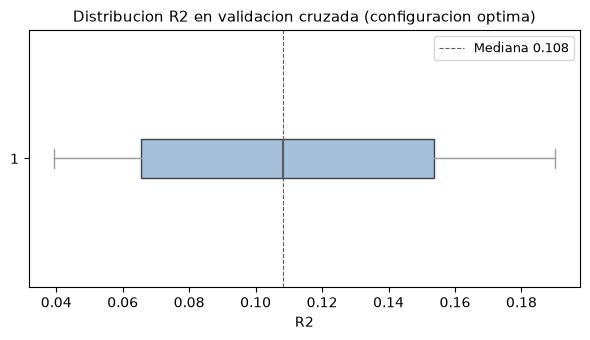

In [9]:
print('Validacion cruzada repetida (15 evaluaciones sobre X_train)...\n')

cv_splitter  = RepeatedKFold(n_splits=5, n_repeats=3, random_state=42)
r2_scores_cv = []

for fold, (train_idx, val_idx) in enumerate(cv_splitter.split(X_train)):
    _, r2 = entrenar_mlp_custom(
        X_train.iloc[train_idx], y_train.iloc[train_idx],
        X_train.iloc[val_idx],   y_train.iloc[val_idx],
        MLP_CONFIG['hidden'],    MLP_CONFIG['dropout'],
        MLP_CONFIG['lr'],        MLP_CONFIG['epochs'],
        MLP_CONFIG['batch'],     MLP_CONFIG['lambda_corr']
    )
    r2_scores_cv.append(r2)
    if (fold + 1) % 5 == 0:
        print(f'  Pliegues completados: {fold+1}/15  |  R2 medio hasta ahora: {np.mean(r2_scores_cv):.4f}')

print(f'\n  R2 medio CV : {np.mean(r2_scores_cv):.4f}')
print(f'  Desviacion  : {np.std(r2_scores_cv):.4f}')
print(f'  Minimo      : {np.min(r2_scores_cv):.4f}')
print(f'  Maximo      : {np.max(r2_scores_cv):.4f}')

# Grafico: distribucion R2 CV (boxplot) 
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.boxplot(r2_scores_cv, vert=False, patch_artist=True,
           boxprops=dict(facecolor=PALETTE['blue'], alpha=0.7),
           medianprops=dict(color=PALETTE['gray_dark'], linewidth=1.5),
           whiskerprops=dict(color=PALETTE['gray']),
           capprops=dict(color=PALETTE['gray']),
           flierprops=dict(marker='o', color=PALETTE['gray'], markersize=4))
ax.set_xlabel('R2')
ax.set_title('Distribucion R2 en validacion cruzada (configuracion optima)', fontsize=11)
ax.axvline(np.median(r2_scores_cv), color=PALETTE['gray_dark'], linestyle='--', linewidth=0.8, label=f'Mediana {np.median(r2_scores_cv):.3f}')
ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


## 5. Importancia de variables

Se usa permutation importance sobre `X_train` mediante un wrapper sklearn. Al igual que en el MLP estandar, la importancia es global sobre los 11 targets. Adicionalmente se muestra la matriz de correlacion aprendida por el modelo comparada con la matriz de correlacion real de los datos de entrenamiento, para verificar que la perdida personalizada esta funcionando.

Entrenando modelo de referencia para analisis...

Top 10 variables más revelantes por permutación:
soil_ph_z                0.1519
dem_elevacion_m_z        0.0850
gee_temp_media_C_z       0.0790
eu_ph_z                  0.0724
gee_humedad_rel_pct_z    0.0696
gee_ndvi_verano_z        0.0677
eu_p_z                   0.0667
silt_content_z           0.0546
clay_content_z           0.0495
mo_z                     0.0484

Top 10 variables menos revelantes por permutación:
cu_z                           0.0122
as_z                           0.0190
ni_z                           0.0255
soil_moisture_z                0.0267
pb_z                           0.0284
eu_water_holding_capacity_z    0.0287
zn_z                           0.0296
eu_sand_content_z              0.0309
eu_zn_z                        0.0310
plot_total_n_z                 0.0331

Diferencia media entre matrices de correlación (real vs predicha): 0.1180
(Valor cercano a 0 indica que la pérdida personalizada está preservando la

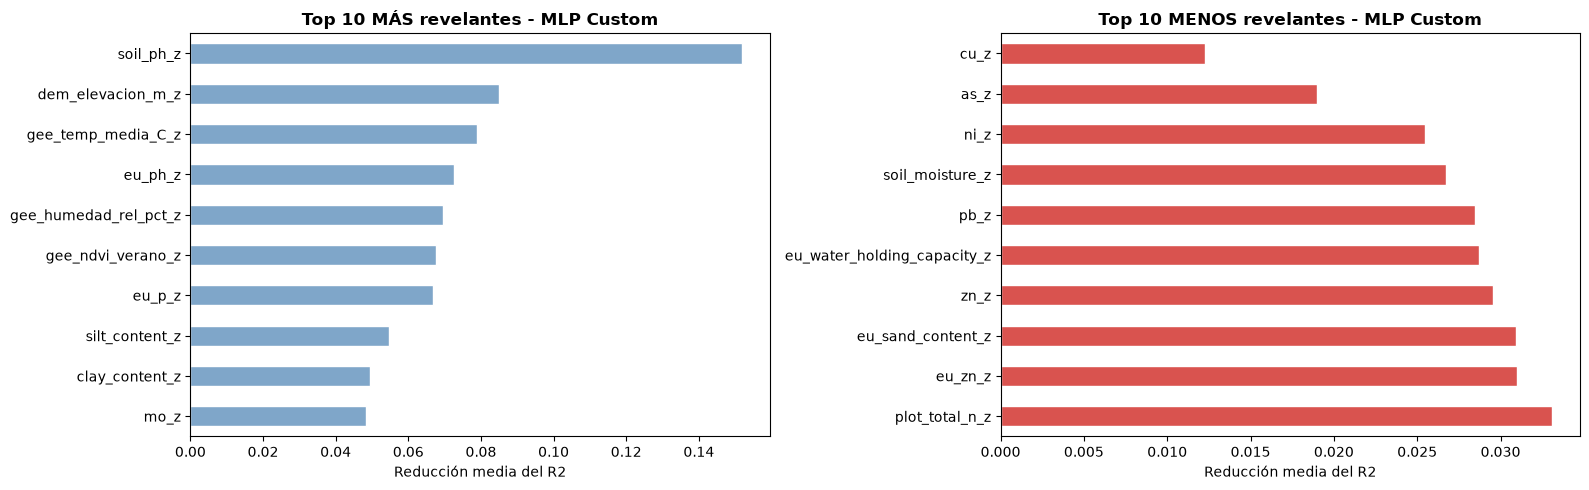

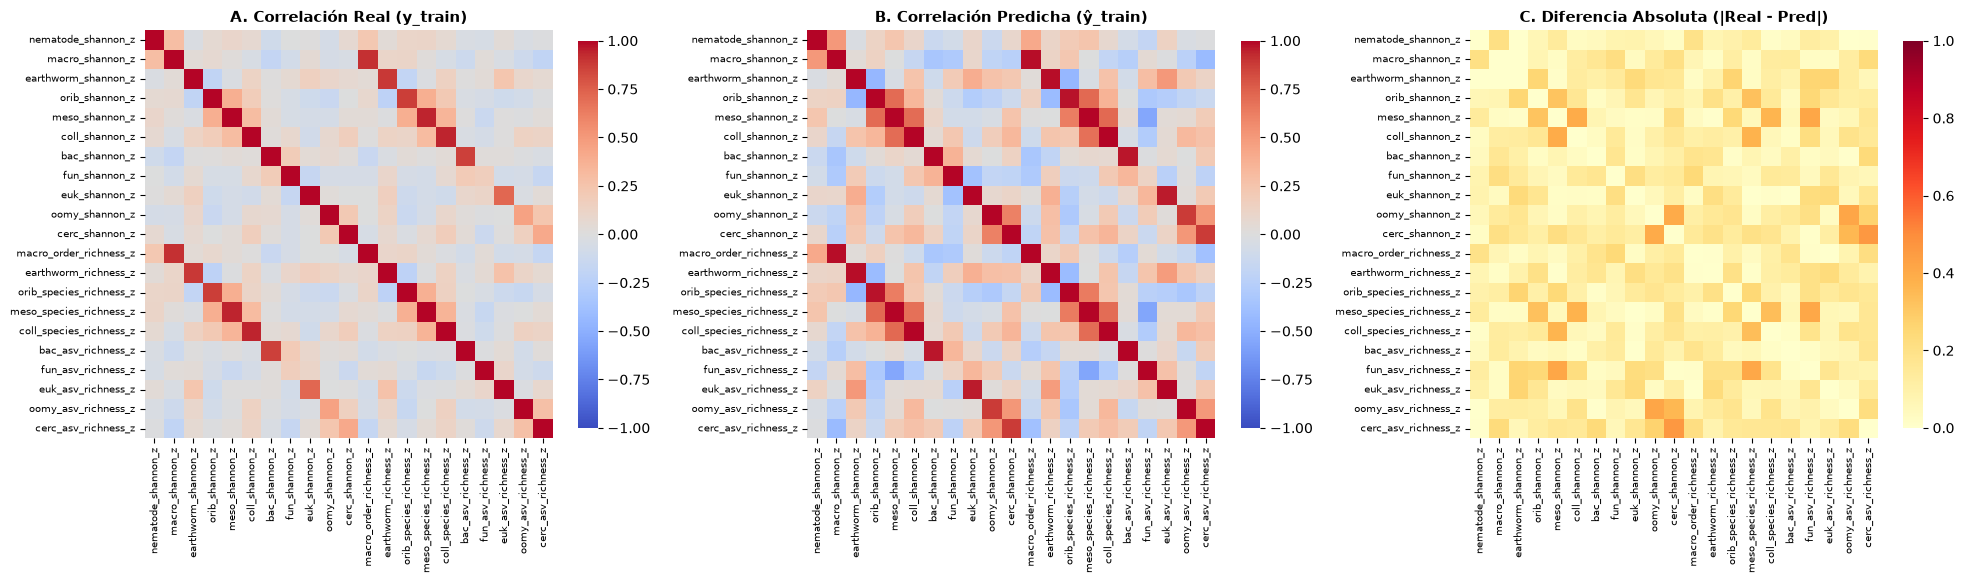

In [ ]:
print('Entrenando modelo de referencia para analisis...\n')

# 1. Entrenamiento del modelo con pérdida personalizada
modelo_ref, _ = entrenar_mlp_custom(
    X_train, y_train, X_test, y_test,
    MLP_CONFIG['hidden'], MLP_CONFIG['dropout'],
    MLP_CONFIG['lr'],     MLP_CONFIG['epochs'],
    MLP_CONFIG['batch'],  MLP_CONFIG['lambda_corr']
)

# 2. Wrapper para compatibilidad con Scikit-Learn
class MLPWrapper(BaseEstimator, RegressorMixin):
    def __init__(self, model):
        self.model = model
    def fit(self, X, y): return self
    def predict(self, X):
        X_t = torch.tensor(np.array(X), dtype=torch.float32).to(DEVICE)
        self.model.eval()
        with torch.no_grad():
            return self.model(X_t).cpu().numpy()

wrapper = MLPWrapper(modelo_ref)

# 3. Cálculo de importancia por permutación
perm = permutation_importance(wrapper, X_train, y_train, n_repeats=10, random_state=42)
importancias = pd.Series(perm.importances_mean, index=FEATURES_AUTORIZADAS)

top10_imp = importancias.nlargest(10)
bottom10_imp = importancias.nsmallest(10)

print('Top 10 variables más revelantes por permutación:')
print(top10_imp.round(4).to_string())

print('\nTop 10 variables menos revelantes por permutación:')
print(bottom10_imp.round(4).to_string())

# 4. Comparación de matrices de correlación (Real vs Predicha)
y_pred_train = wrapper.predict(X_train)
corr_real  = pd.DataFrame(y_train.values, columns=TARGETS).corr()
corr_pred  = pd.DataFrame(y_pred_train,   columns=TARGETS).corr()
diff_corr  = (corr_real - corr_pred).abs()

print(f'\nDiferencia media entre matrices de correlación (real vs predicha): {diff_corr.values.mean():.4f}')
print('(Valor cercano a 0 indica que la pérdida personalizada está preservando las correlaciones.)')

# 5. Exportación a CSV
ruta_top_csv = './output/var/variables_mas_revelantes_mlp_custom.csv'
ruta_bottom_csv = './output/var/variables_menos_revelantes_mlp_custom.csv'
ruta_corr_csv = './output/var/diferencia_correlaciones_mlp_custom.csv'

top10_imp.to_csv(ruta_top_csv, header=['importancia_permutacion'], index_label='variable')
bottom10_imp.to_csv(ruta_bottom_csv, header=['importancia_permutacion'], index_label='variable')
diff_corr.to_csv(ruta_corr_csv, index_label='target')

print(f"Datos exportados correctamente para revisión en: '{ruta_top_csv}'")
print(f"Datos exportados correctamente para revisión en: '{ruta_bottom_csv}'")
print(f"Datos exportados correctamente para revisión en: '{ruta_corr_csv}'")


# GRÁFICA 1: Comparativa de Importancia de Variables (Más vs Menos revelantes)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Subplot A: Más revelantes
top10_imp.sort_values().plot(kind='barh', ax=axes[0], color=PALETTE.get('blue', '#2b5c8f'), edgecolor='white')
axes[0].set_title('Top 10 MÁS revelantes - MLP Custom', fontsize=12, fontweight='bold')
axes[0].set_xlabel('Reducción media del R2')
axes[0].set_ylabel('')

# Subplot B: Menos revelantes
bottom10_imp.sort_values(ascending=False).plot(kind='barh', ax=axes[1], color=PALETTE.get('red', '#d9534f'), edgecolor='white')
axes[1].set_title('Top 10 MENOS revelantes - MLP Custom', fontsize=12, fontweight='bold')
axes[1].set_xlabel('Reducción media del R2')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()


# GRÁFICA 2: Heatmaps de Preservación de Correlación entre Targets

fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Heatmap Real
sns.heatmap(corr_real, ax=axes[0], cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={'shrink': 0.8}, square=True)
axes[0].set_title('A. Correlación Real (y_train)', fontsize=11, fontweight='bold')

# Heatmap Predicha
sns.heatmap(corr_pred, ax=axes[1], cmap='coolwarm', vmin=-1, vmax=1, cbar_kws={'shrink': 0.8}, square=True)
axes[1].set_title('B. Correlación Predicha (ŷ_train)', fontsize=11, fontweight='bold')

# Heatmap Diferencia
sns.heatmap(diff_corr, ax=axes[2], cmap='YlOrRd', vmin=0, vmax=1, cbar_kws={'shrink': 0.8}, square=True)
axes[2].set_title('C. Diferencia Absoluta (|Real - Pred|)', fontsize=11, fontweight='bold')

for ax in axes:
    ax.tick_params(axis='x', labelsize=7, labelrotation=90)
    ax.tick_params(axis='y', labelsize=7, labelrotation=0)

plt.tight_layout()
plt.show()

## 6. Entrenamiento de produccion

Se entrena un ensamble de 5 redes con semillas distintas usando la perdida personalizada. Los pesos se guardan como `.pt` y la configuracion de arquitectura como `.pkl`.

In [11]:
print('Entrenamiento de produccion (ensamble de 5 redes con perdida personalizada)...')
print('-' * 70)

global_start = time.time()
NUM_REDES    = 5

for seed_id in range(NUM_REDES):
    t0 = time.time()
    torch.manual_seed(42 + seed_id)
    np.random.seed(42 + seed_id)

    model, r2_test = entrenar_mlp_custom(
        X_train, y_train, X_test, y_test,
        MLP_CONFIG['hidden'], MLP_CONFIG['dropout'],
        MLP_CONFIG['lr'],     MLP_CONFIG['epochs'],
        MLP_CONFIG['batch'],  MLP_CONFIG['lambda_corr']
    )
    ruta = os.path.join(MODELS_DIR, f'mlp_custom_{seed_id}.pt')
    torch.save(model.state_dict(), ruta)
    print(f'  Red {seed_id+1}/5 | R2 test: {r2_test:.4f} | ({time.time()-t0:.1f}s)')

joblib.dump(MLP_CONFIG, os.path.join(MODELS_DIR, 'mlp_custom_config.pkl'))

print('-' * 70)
print(f'Produccion completada en {(time.time()-global_start)/60:.1f} minutos.')


Entrenamiento de produccion (ensamble de 5 redes con perdida personalizada)...
----------------------------------------------------------------------
  Red 1/5 | R2 test: 0.1084 | (3.5s)
  Red 2/5 | R2 test: 0.1145 | (3.4s)
  Red 3/5 | R2 test: 0.1341 | (3.4s)
  Red 4/5 | R2 test: 0.1094 | (3.8s)
  Red 5/5 | R2 test: 0.1286 | (4.2s)
----------------------------------------------------------------------
Produccion completada en 0.3 minutos.


In [ ]:

# PRUEBA 3 - Barrido de random_state (0-100)

RANDOM_STATES = range(0, 101)
dir_barrido   = os.path.join(MODELS_DIR, 'barrido_rs_mlp_custom')
os.makedirs(dir_barrido, exist_ok=True)

resultados_rs = []
t_inicio = time.time()

for rs in RANDOM_STATES:
    t0 = time.time()
    torch.manual_seed(rs)
    np.random.seed(rs)

    model, _ = entrenar_mlp_custom(
        X_train, y_train, X_test, y_test,
        MLP_CONFIG['hidden'], MLP_CONFIG['dropout'],
        MLP_CONFIG['lr'], MLP_CONFIG['epochs'], MLP_CONFIG['batch'],
        MLP_CONFIG['lambda_corr']
    )

    model.eval()
    with torch.no_grad():
        X_eval_t    = torch.tensor(X_eval.values, dtype=torch.float32).to(DEVICE)
        y_pred_eval = model(X_eval_t).cpu().numpy()
    y_true_eval = y_eval.values

    fila = {
        'random_state': rs,
        'r2_global':   r2_score(y_true_eval, y_pred_eval, multioutput='uniform_average'),
        'rmse_global': np.sqrt(mean_squared_error(y_true_eval, y_pred_eval, multioutput='uniform_average')),
        'mae_global':  mean_absolute_error(y_true_eval, y_pred_eval, multioutput='uniform_average'),
    }
    for t, r2_t in zip(TARGETS, r2_score(y_true_eval, y_pred_eval, multioutput='raw_values')):
        fila[f'{t}_r2'] = r2_t

    torch.save(model.state_dict(), os.path.join(dir_barrido, f'mlp_custom_prod_rs{rs}.pt'))
    resultados_rs.append(fila)
    if rs % 10 == 0:
        print(f'  rs={rs:3d} completado ({time.time()-t0:.1f}s)')

df_barrido_mlp_custom = pd.DataFrame(resultados_rs)
df_barrido_mlp_custom.to_csv(os.path.join(dir_barrido, 'mlp_custom_barrido_rs.csv'), index=False)
print(f'\nBarrido completado en {(time.time()-t_inicio)/60:.1f} minutos.')

## 7. Evaluacion final y prueba de funcionamiento

Esta seccion tiene dos partes:

**Parte A - Evaluacion final**
Se mide por primera vez el rendimiento sobre `eval.csv`. Se muestran metricas globales (promedio sobre los 11 targets) y R2 individual por target.

**Parte B - Smoke test**
Se verifica que el pipeline funciona de extremo a extremo con 3 filas reales de `eval.csv`, comparando la prediccion con el valor real observado.

---
**Como leer el indice Shannon H':**
Cada target es el indice de diversidad de Shannon de un grupo biologico distinto. El valor va de `0.0` (sin diversidad) a `4.0-5.0` (alta diversidad). Un valor tipico en suelos agricolas europeos se situa entre `1.5` y `2.5`.

Evaluacion final sobre eval.csv
------------------------------------------------------------
  R2   global: -0.1320
  RMSE global: 0.9862 puntos de Shannon H'
  MAE  global: 0.7187 puntos de Shannon H'

  Diferencia media de correlacion en eval.csv: 0.1725

  R2 por target:
    nematode_shannon_z             0.0908
    macro_shannon_z                0.2684
    earthworm_shannon_z            0.3748
    orib_shannon_z                 0.2209
    meso_shannon_z                 -0.6200
    coll_shannon_z                 -1.3473
    bac_shannon_z                  -0.0998
    fun_shannon_z                  -0.0843
    euk_shannon_z                  0.0877
    oomy_shannon_z                 0.0588
    cerc_shannon_z                 -0.1193
    macro_order_richness_z         0.3773
    earthworm_richness_z           0.4671
    orib_species_richness_z        0.2534
    meso_species_richness_z        -0.3475
    coll_species_richness_z        -2.2471
    bac_asv_richness_z             -0.1676
   

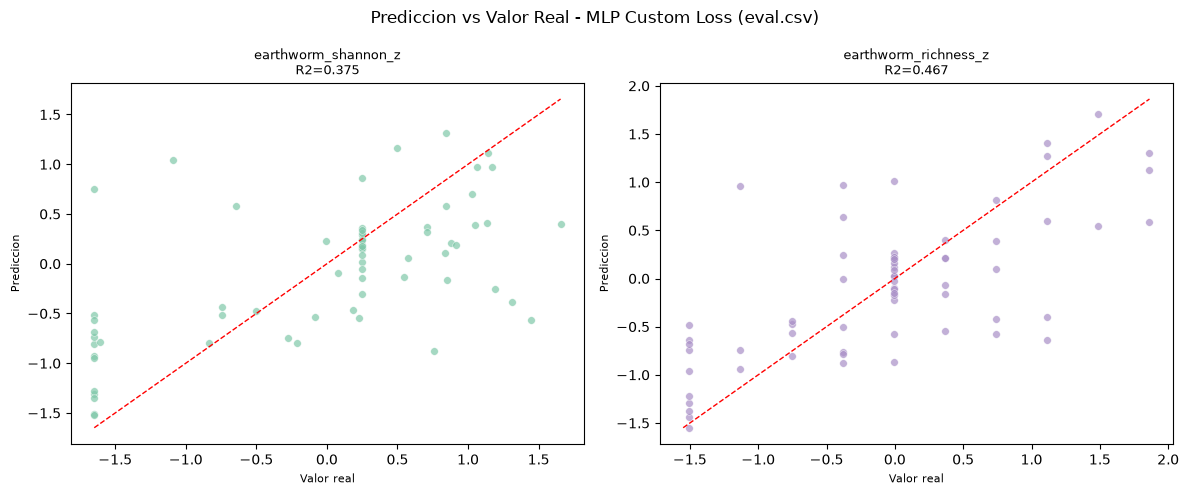

In [12]:
NUM_REDES = 5


# Evaluacion final

print('Evaluacion final sobre eval.csv')
print('-' * 60)

cfg_prod   = joblib.load(os.path.join(MODELS_DIR, 'mlp_custom_config.pkl'))
preds_eval = []

for seed_id in range(NUM_REDES):
    model = MLPMultiSalida(
        len(FEATURES_AUTORIZADAS), len(TARGETS),
        cfg_prod['hidden'], cfg_prod['dropout']
    ).to(DEVICE)
    model.load_state_dict(torch.load(
        os.path.join(MODELS_DIR, f'mlp_custom_{seed_id}.pt'), map_location=DEVICE
    ))
    model.eval()
    with torch.no_grad():
        X_eval_t = torch.tensor(X_eval.values, dtype=torch.float32).to(DEVICE)
        preds_eval.append(model(X_eval_t).cpu().numpy())

y_pred_eval = np.mean(preds_eval, axis=0)
y_true_eval = y_eval.values

r2_global   = r2_score(y_true_eval, y_pred_eval, multioutput='uniform_average')
rmse_global = np.sqrt(mean_squared_error(y_true_eval, y_pred_eval, multioutput='uniform_average'))
mae_global  = mean_absolute_error(y_true_eval, y_pred_eval, multioutput='uniform_average')

print(f'  R2   global: {r2_global:.4f}')
print(f'  RMSE global: {rmse_global:.4f} puntos de Shannon H\'')
print(f'  MAE  global: {mae_global:.4f} puntos de Shannon H\'')

# Verificacion de correlaciones sobre eval.csv
corr_real_eval = pd.DataFrame(y_true_eval, columns=TARGETS).corr()
corr_pred_eval = pd.DataFrame(y_pred_eval, columns=TARGETS).corr()
diff_eval      = (corr_real_eval - corr_pred_eval).abs().values.mean()
print(f'\n  Diferencia media de correlacion en eval.csv: {diff_eval:.4f}')

print('\n  R2 por target:')
for t, r2 in zip(TARGETS, r2_score(y_true_eval, y_pred_eval, multioutput='raw_values')):
    print(f'    {t:30} {r2:.4f}')


# Smoke test

print('\nSmoke test - Inferencia con datos reales')
print('-' * 60)

try:
    df_new_data      = X_eval.sample(n=3, random_state=42)
    indices_elegidos = df_new_data.index

    votos = []
    for seed_id in range(NUM_REDES):
        model = MLPMultiSalida(
            len(FEATURES_AUTORIZADAS), len(TARGETS),
            cfg_prod['hidden'], cfg_prod['dropout']
        ).to(DEVICE)
        model.load_state_dict(torch.load(
            os.path.join(MODELS_DIR, f'mlp_custom_{seed_id}.pt'), map_location=DEVICE
        ))
        model.eval()
        with torch.no_grad():
            X_new_t = torch.tensor(df_new_data.values, dtype=torch.float32).to(DEVICE)
            pred    = model(X_new_t).cpu().numpy()
        votos.append(pred)
        idx_e = TARGETS.index('earthworm_shannon_z')
        print(f'  Red {seed_id+1} | '
              f'Fila {indices_elegidos[0]}: {pred[0, idx_e]:.4f} | '
              f'Fila {indices_elegidos[1]}: {pred[1, idx_e]:.4f} | '
              f'Fila {indices_elegidos[2]}: {pred[2, idx_e]:.4f}  (earthworm_shannon_z)')

    consenso = np.mean(votos, axis=0)
    idx_earth = TARGETS.index('earthworm_shannon_z')

    print('-' * 60)
    print('  Resultados detallados por muestra (earthworm_shannon_z):')
    print('-' * 60)

    for i, idx in enumerate(indices_elegidos):
        pred_val = consenso[i, idx_earth]
        real_val = y_eval.loc[idx, 'earthworm_shannon_z']
        error    = abs(pred_val - real_val)
        print(f'    Fila {idx:<4} | Prediccion: {pred_val:.4f} | '
              f'Valor Real: {real_val:.4f} | Error absoluto: {error:.4f}')

    print('-' * 60)
    print('\nSmoke test superado. El pipeline MLP con perdida personalizada funciona correctamente.')

except Exception as e:
    print(f'Error en el smoke test: {str(e)}')


# Grafico: scatter prediccion vs valor real (targets principales)
_targets_plot = ['earthworm_shannon_z', 'earthworm_richness_z']
_colors_plot  = [PALETTE['green'], PALETTE['purple']]
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, tgt, col in zip(axes, _targets_plot, _colors_plot):
    idx_col = TARGETS.index(tgt)
    yp = y_pred_eval[:, idx_col]
    yt = y_true_eval[:, idx_col]
    ax.scatter(yt, yp, alpha=0.7, s=30, color=col, edgecolors='white', linewidths=0.4)
    lim = [min(yt.min(), yp.min()), max(yt.max(), yp.max())]
    ax.plot(lim, lim, 'r--', linewidth=1)
    ax.set_title(f'{tgt}\nR2={r2_score(yt, yp):.3f}', fontsize=9)
    ax.set_xlabel('Valor real', fontsize=8)
    ax.set_ylabel('Prediccion', fontsize=8)
plt.suptitle('Prediccion vs Valor Real - MLP Custom Loss (eval.csv)', fontsize=12)
plt.tight_layout()
plt.show()